# Project 1

# Importing required packages and libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data into Pandas

In [2]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

In [3]:
df.head(20)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [5]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [7]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [8]:
missing_percentage = df.isnull().mean() * 100

missing_percentage

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

# Data Preparation

### Handling Missing Values

In [9]:
df['CouponCode'].values

array(['SAVE10', 'SAVE10', 'FREESHIP', ..., 'FREESHIP', 'WINTER15',
       'SAVE10'], shape=(1200,), dtype=object)

In [10]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [11]:
x = df['CouponCode'].values.shape
x

(1200,)

In [12]:
type(x[0])

int

In [13]:
print(' Percentage of null values for CouponCode column: ', (df['CouponCode'].isna().sum() / x[0]) * 100, '%' )

 Percentage of null values for CouponCode column:  25.75 %


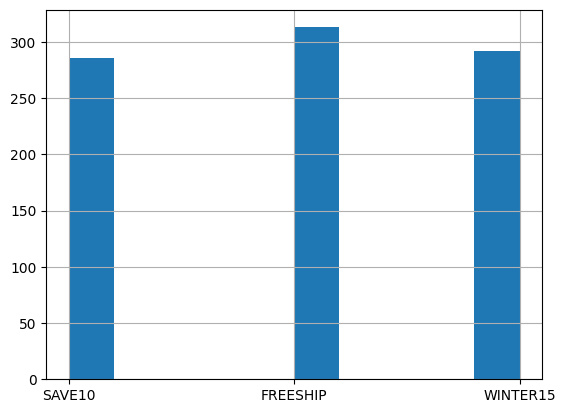

In [14]:
df['CouponCode'].hist()

plt.show()

In [15]:
'''
Due to the nature of the column with missing values (object type) and the percentage (25.75%), it would not be best practice to drop the missing rows
Also, due to the percentage (25.75%) I am considering that the nan values may hold a deeper meaning: maybe those customers did not use a coupon code, or were not given the option to use one.
Due to this logic, instead of filling the values with the Mode, I would be filling it with a constant 'Unknown' to signify its special nature
'''

"\nDue to the nature of the column with missing values (object type) and the percentage (25.75%), it would not be best practice to drop the missing rows\nAlso, due to the percentage (25.75%) I am considering that the nan values may hold a deeper meaning: maybe those customers did not use a coupon code, or were not given the option to use one.\nDue to this logic, instead of filling the values with the Mode, I would be filling it with a constant 'Unknown' to signify its special nature\n"

In [16]:
df['CouponCode'] = df['CouponCode'].fillna('Unknown').copy()

df['CouponCode']

0         SAVE10
1         SAVE10
2       FREESHIP
3         SAVE10
4         SAVE10
          ...   
1195    FREESHIP
1196     Unknown
1197    FREESHIP
1198    WINTER15
1199      SAVE10
Name: CouponCode, Length: 1200, dtype: object

In [17]:
df.isna().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [18]:
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed')

df['Date']

0      2023-01-04
1      2024-08-23
2      2024-02-27
3      2023-10-15
4      2025-05-08
          ...    
1195   2024-06-20
1196   2024-03-04
1197   2023-07-13
1198   2024-08-22
1199   2023-06-11
Name: Date, Length: 1200, dtype: datetime64[ns]

### Handling Outliers

In [19]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [20]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns

num_cols

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')

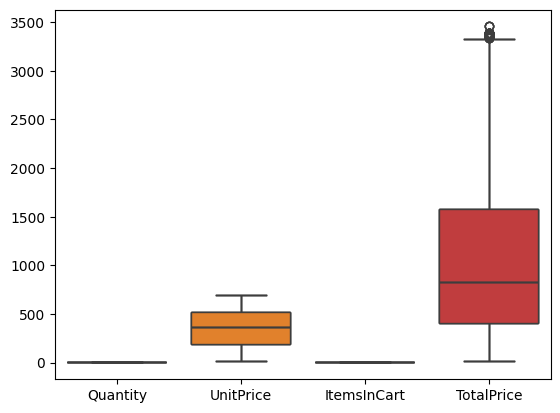

In [21]:
for i in num_cols:
    sns.boxplot(data = df[num_cols])
    plt.savefig('Outliers.jpg')

#### Quantity column

In [22]:
# Calculate the 3rd quartile and 1st quartile
print(df['Quantity'])
q1 = df['Quantity'].quantile(0.25)
print(q1)
q3 = df['Quantity'].quantile(0.75)
print(q3)
iqr = q3 - q1
print(iqr)

upper = q3 + (1.5 * iqr)

lower = q1 - (1.5 * iqr)

print(f' Upper limit = {upper}, Lower limit = {lower}')

outliers = df[df['Quantity'] > upper]

print(outliers['Quantity'])

0       5
1       2
2       5
3       1
4       4
       ..
1195    1
1196    2
1197    2
1198    4
1199    4
Name: Quantity, Length: 1200, dtype: int64
2.0
4.0
2.0
 Upper limit = 7.0, Lower limit = -1.0
Series([], Name: Quantity, dtype: int64)


#### UnitPrice column

In [23]:
# Calculate the 3rd quartile and 1st quartile
print(df['UnitPrice'])
q1 = df['UnitPrice'].quantile(0.25)
print(q1)
q3 = df['UnitPrice'].quantile(0.75)
print(q3)
iqr = q3 - q1
print(iqr)

upper = q3 + (1.5 * iqr)

lower = q1 - (1.5 * iqr)

print(f' Upper limit = {upper}, Lower limit = {lower}')

outliers = df[df['UnitPrice'] > upper]

print(outliers['UnitPrice'])

0       570.62
1       151.35
2       550.68
3       273.19
4       626.01
         ...  
1195    107.04
1196    662.53
1197    436.84
1198    262.52
1199    560.58
Name: UnitPrice, Length: 1200, dtype: float64
186.0625
521.5699999999999
335.50749999999994
 Upper limit = 1024.8312499999997, Lower limit = -317.1987499999999
Series([], Name: UnitPrice, dtype: float64)


#### ItemsInCart column

In [24]:
# Calculate the 3rd quartile and 1st quartile
print(df['ItemsInCart'])
q1 = df['ItemsInCart'].quantile(0.25)
print(q1)
q3 = df['ItemsInCart'].quantile(0.75)
print(q3)
iqr = q3 - q1
print(iqr)

upper = q3 + (1.5 * iqr)

lower = q1 - (1.5 * iqr)

print(f' Upper limit = {upper}, Lower limit = {lower}')

outliers = df[df['ItemsInCart'] > upper]

print(outliers['ItemsInCart'])

0       7
1       3
2       8
3       5
4       8
       ..
1195    6
1196    5
1197    2
1198    4
1199    6
Name: ItemsInCart, Length: 1200, dtype: int64
4.0
7.0
3.0
 Upper limit = 11.5, Lower limit = -0.5
Series([], Name: ItemsInCart, dtype: int64)


#### TotalPrice column

In [25]:
# Calculate the 3rd quartile and 1st quartile
print(df['TotalPrice'])
q1 = df['TotalPrice'].quantile(0.25)
print(q1)
q3 = df['TotalPrice'].quantile(0.75)
print(q3)
iqr = q3 - q1
print(iqr)

upper = q3 + (1.5 * iqr)

lower = q1 - (1.5 * iqr)

print(f' Upper limit = {upper}, Lower limit = {lower}')

outliers = df[df['TotalPrice'] > upper]

print(outliers['TotalPrice'])

0       2853.10
1        302.70
2       2753.40
3        273.19
4       2504.04
         ...   
1195     107.04
1196    1325.06
1197     873.68
1198    1050.08
1199    2242.32
Name: TotalPrice, Length: 1200, dtype: float64
410.52
1578.475
1167.955
 Upper limit = 3330.4075, Lower limit = -1341.4125
107     3353.75
326     3352.40
328     3370.20
469     3384.90
632     3390.80
789     3456.40
1065    3334.00
1122    3390.95
Name: TotalPrice, dtype: float64


In [26]:
np.mean(outliers['TotalPrice'] - upper)

np.float64(48.76750000000021)

In [27]:
df[df['TotalPrice'] >= 3334.00 ]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,Unknown,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,Unknown,Facebook,3390.95


In [28]:
'''
The values which are outliers for the TotalPrice column seem to be important and insightful to delete for being outliers
Hence I have decided to cap their values at the upper limit to prevent them from dominating and influencing the distribution of the data
'''

'\nThe values which are outliers for the TotalPrice column seem to be important and insightful to delete for being outliers\nHence I have decided to cap their values at the upper limit to prevent them from dominating and influencing the distribution of the data\n'

##### Winsorization of the Outliers in TotalPrice column

In [29]:
df['TotalPrice'] = df['TotalPrice'].clip(
    lower = lower,
    upper = upper
)



In [30]:
df['TotalPrice'].describe()

count    1200.000000
mean     1053.643183
std       818.937858
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3330.407500
Name: TotalPrice, dtype: float64

# Feature Engineering

In [31]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [32]:
df.head(51)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,Unknown,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


#### Month column

In [33]:
df['Month'] = df['Date'].dt.strftime("%b")

df['Month']

0       Jan
1       Aug
2       Feb
3       Oct
4       May
       ... 
1195    Jun
1196    Mar
1197    Jul
1198    Aug
1199    Jun
Name: Month, Length: 1200, dtype: object

#### ProductCategory column

In [34]:
prod_nature = list(df['Product'].unique())

prod_nature

['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']

In [35]:
furniture = ['Chair', 'Desk']
gadget = ['Phone', 'Tablet', 'Laptop']
office = ['Monitor', 'Printer']

In [36]:
nature = {
    'Chair' : 'Furniture',
    'Desk' : 'Furniture',
    'Phone' : 'Gadget', 
    'Tablet' : 'Gadget', 
    'Laptop' : 'Gadget',
    'Monitor' : 'Office', 
    'Printer' : 'Office'
}

nature

{'Chair': 'Furniture',
 'Desk': 'Furniture',
 'Phone': 'Gadget',
 'Tablet': 'Gadget',
 'Laptop': 'Gadget',
 'Monitor': 'Office',
 'Printer': 'Office'}

In [37]:
df['ProductCategory'] = df['Product'].map(nature)

df[['Product', 'ProductCategory']]

,Product,ProductCategory
0,Monitor,Office
1,Phone,Gadget
2,Tablet,Gadget
3,Chair,Furniture
4,Printer,Office
...,...,...
1195,Desk,Furniture
1196,Monitor,Office
1197,Tablet,Gadget
1198,Chair,Furniture


#### Discount column

In [38]:
discount = {
    'SAVE10' : 0.1,
    'FREESHIP': 0.2,
    'WINTER15' : 0.15,
    'Unknown' : 0
}

In [39]:
df['Discount'] = [discount[x] for x in df['CouponCode']]

df[['CouponCode','Discount']]

,CouponCode,Discount
0,SAVE10,0.10
1,SAVE10,0.10
2,FREESHIP,0.20
3,SAVE10,0.10
4,SAVE10,0.10
...,...,...
1195,FREESHIP,0.20
1196,Unknown,0.00
1197,FREESHIP,0.20
1198,WINTER15,0.15


#### DiscountApplied

In [40]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', 'Unknown', 'WINTER15'], dtype=object)

In [41]:
def Discount(price, rate):
    new = price * rate
    return round(new, 2)

In [42]:
df['DiscountApplied'] = Discount(df['TotalPrice'], df['Discount'])

df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,ProductCategory,Discount,DiscountApplied
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Jan,Office,0.10,285.31
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Aug,Gadget,0.10,30.27
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Feb,Gadget,0.20,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Oct,Furniture,0.10,27.32
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,May,Office,0.10,250.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,Jun,Furniture,0.20,21.41
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,Unknown,Facebook,1325.06,Mar,Office,0.00,0.00
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,Jul,Gadget,0.20,174.74
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,Aug,Furniture,0.15,157.51


In [43]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month',
       'ProductCategory', 'Discount', 'DiscountApplied'],
      dtype='object')

In [44]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Discount,DiscountApplied
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.643183,0.112500,119.025900
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,0.000000,0.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,0.000000,0.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,0.150000,74.605000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,0.200000,187.515000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3330.407500,0.200000,666.080000
std,NaN,1.407557,197.177146,2.281983,818.937858,0.075101,136.086405


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
 14  Month            1200 non-null   object 

In [46]:
df.to_csv('Cleaned Purchase Dataset.csv', index = False)